## Задание

### Часть 1 (5 балла)
1. Выберите одну любую из задач, рассмотренных на [лекции](https://colab.research.google.com/drive/1B7Np_7y002NLiuNkriq6a6MchQL4Fw7p?usp=sharing) (локализация, сегментация, перенос стиля, генерация).

2. Подберите на kaggle датасет, подходящий для решения этой задачи.
  - Вариант 1: если данные обладают необходимой разметкой, то повторите пайплайн из блокнота с примером на своих данных.
  - Вариант 2: если данные не обладают необходимой разметкой, то используйте модель, которую дообучали в примере, но без дообучения.
3. Оцените и прокомментируйте результат.

### Часть 2 (8 баллов)
1. Выберите еще одну из рассмотренных в лекции задач (не совпадающую с первой).
2. Если ваши данные обладают разметкой, необходимой для новой задачи, продолжите работу с ними. Если нет, найдите другой датасет, в котором она будет. Можно взять какой-нибудь стандартный в PyTorch, но такой, который не встречался ни в одном из примеров с лекции. В этом задании обязательно нужно найти датасет с разметкой.
3. Повторите пайплайн из примера.
4. Постарайтесь улучшить качество результата (если классификация - точность выше 90%, во всех остальных - максимально понизить лосс). Это можно сделать за счет настройки гиперпараметров. Можно (опционально и в зависимости от задачи) также поменять гиперпараметры в слоях нейронных сетей и/или порядок слоев и/или их количество.

В заданиях, где перечислены два варианта выполнения, нужно выбрать только один. Выполнение обоих дополнительных баллов не дает.



## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе тестов нет.
- Эту работу можно выполнить с кем-нибудь в паре или в гордом одиночестве.
- Пул-реквест нужно сделать в ветку `lab3`. Если вас двое, то можно 1 или 2 пул-реквеста, главное – отметьте как-нибудь, что выполняли в паре.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**

In [2]:
# Импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Параметры
latent_dim = 100  # Размер вектора шума
batch_size = 128
epochs = 5
lr = 0.0002
image_size = 32
channels = 3  # Для цветных изображений (RGB)


In [3]:
# Загрузка данных CIFAR-10
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_data = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(cifar_data, batch_size=batch_size, shuffle=True)


100%|██████████| 170M/170M [00:02<00:00, 73.6MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


In [4]:
# Генератор
class Generator(nn.Module):
    def __init__(self, input_dim, img_channels):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, img_channels * image_size * image_size),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), channels, image_size, image_size)
        return img


In [5]:
# Дискриминатор
class Discriminator(nn.Module):
    def __init__(self, img_channels):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(img_channels * image_size * image_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity


In [6]:
# Инициализация сетей
generator = Generator(latent_dim, channels)
discriminator = Discriminator(channels)

# Оптимизаторы
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Функция потерь
adversarial_loss = nn.BCELoss()

# Устройство (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator.to(device)
discriminator.to(device)
adversarial_loss.to(device)


BCELoss()

In [7]:
# Тренировка
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        real_labels = torch.ones((imgs.size(0), 1), device=device)
        fake_labels = torch.zeros((imgs.size(0), 1), device=device)

        # Обучение дискриминатора
        real_imgs = imgs.to(device)
        optimizer_D.zero_grad()
        real_loss = adversarial_loss(discriminator(real_imgs), real_labels)

        z = torch.randn((imgs.size(0), latent_dim), device=device)
        fake_imgs = generator(z)
        fake_loss = adversarial_loss(discriminator(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Обучение генератора
        optimizer_G.zero_grad()
        g_loss = adversarial_loss(discriminator(fake_imgs), real_labels)
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch + 1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch [1/5] | D Loss: 0.6804 | G Loss: 1.3530
Epoch [2/5] | D Loss: 1.1796 | G Loss: 5.1902
Epoch [3/5] | D Loss: 0.9157 | G Loss: 5.4159
Epoch [4/5] | D Loss: 1.0799 | G Loss: 4.9218
Epoch [5/5] | D Loss: 0.2511 | G Loss: 4.7321


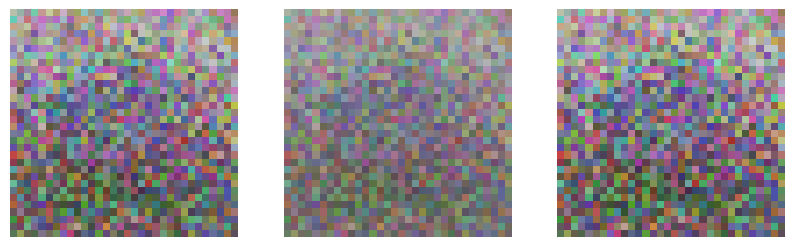

In [16]:
# Генерация изображений
generator.eval()
z = torch.randn((3, latent_dim), device=device)  # Создаем 3 случайных вектора шума
generated_imgs = generator(z)

# Визуализация изображений
generated_imgs = generated_imgs.cpu().detach()
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    # Преобразование изображений из [-1, 1] в [0, 1]
    img = (generated_imgs[i].permute(1, 2, 0) + 1) / 2
    ax.imshow(img)
    ax.axis("off")
plt.show()
